# 04 — Preprocessing & Dataset Verification

Verifies the caching pipeline, Dataset class, augmentations, labels, and batch loading speed.

In [1]:
import sys, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from pathlib import Path

from src.data.preprocess import (
    load_audio, compute_melspec, segment_waveform,
    cache_spectrograms, DEFAULT_SR, DEFAULT_HOP_LENGTH,
)
from src.data.augmentations import spec_augment, gaussian_noise, mixup
from src.data.dataset import BirdCLEFDataset

plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('../data/raw')
AUDIO_DIR = DATA_DIR / 'train_audio'
SPEC_DIR = Path('../data/processed')
FOLDS_CSV = Path('../data/folds/folds.csv')
TRAIN_CSV = DATA_DIR / 'train.csv'

meta = pd.read_csv(TRAIN_CSV)
folds = pd.read_csv(FOLDS_CSV)
print(f'Total files: {len(meta)}, Folds entries: {len(folds)}')

Total files: 35549, Folds entries: 35549


## 1 — Build target species list

In [2]:
# Try taxonomy or sample_submission first; fall back to unique primary_labels
tax_path = DATA_DIR / 'taxonomy.csv'
ss_path  = DATA_DIR / 'sample_submission.csv'

if tax_path.exists():
    tax = pd.read_csv(tax_path)
    # species code column is usually 'primary_label' or 'species_code'
    col = 'primary_label' if 'primary_label' in tax.columns else tax.columns[0]
    target_species = sorted(tax[col].unique().tolist())
elif ss_path.exists():
    ss = pd.read_csv(ss_path)
    target_species = sorted([c for c in ss.columns if c not in ('row_id', 'filename')])
else:
    target_species = sorted(meta['primary_label'].unique().tolist())

print(f'Target species: {len(target_species)}')
print(target_species[:10], '...')

Target species: 234
['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967'] ...


## 2 — Cache spectrograms for a small subset (10 species, ~50 clips)

In [3]:
species_counts = meta['primary_label'].value_counts()
subset_species = species_counts.head(5).index.tolist() + species_counts.tail(5).index.tolist()
subset_df = meta[meta['primary_label'].isin(subset_species)]
subset_files = subset_df.groupby('primary_label').head(5)['filename'].tolist()
print(f'Subset: {len(subset_species)} species, {len(subset_files)} clips')

stats = cache_spectrograms(
    audio_dir=str(AUDIO_DIR),
    output_dir=str(SPEC_DIR),
    file_list=subset_files,
)
print(stats)

Subset: 10 species, 31 clips
Done. processed=0 skipped=31 failed=0
{'processed': 0, 'skipped': 31, 'failed': 0, 'errors': []}


Loaded: iNat1460166.npy  shape=(128, 492)  dtype=float32
Value range: [-80.0, 0.0]


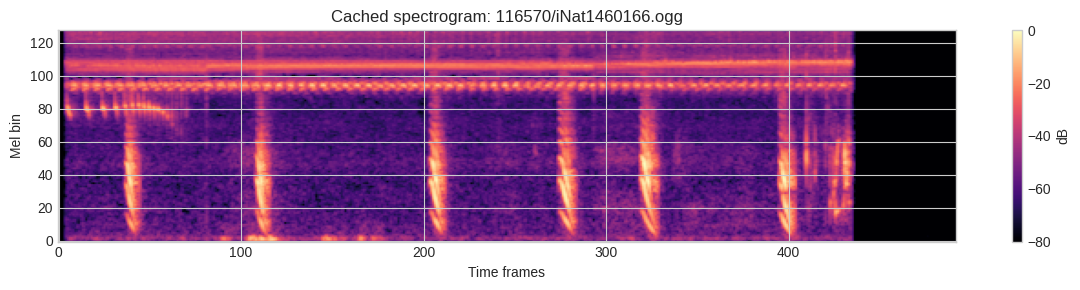

In [4]:
# Verify .npy files exist and look correct
sample_file = subset_files[0]
npy_path = SPEC_DIR / Path(sample_file).with_suffix('.npy')
spec = np.load(str(npy_path))
print(f'Loaded: {npy_path.name}  shape={spec.shape}  dtype={spec.dtype}')
print(f'Value range: [{spec.min():.1f}, {spec.max():.1f}]')

plt.figure(figsize=(12, 3))
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label='dB')
plt.title(f'Cached spectrogram: {sample_file}')
plt.xlabel('Time frames')
plt.ylabel('Mel bin')
plt.tight_layout()
plt.show()

## 3 — Dataset: train & val mode, pull 5 batches

In [5]:
# Build a mini folds CSV for the subset
sub_folds = folds[folds['filename'].isin(subset_files)].copy()
sub_folds_path = Path('/tmp/sub_folds.csv')
sub_folds.to_csv(sub_folds_path, index=False)
print(f'Subset folds: {len(sub_folds)} rows')

ds_train = BirdCLEFDataset(
    folds_csv=sub_folds_path, fold=0, mode='train',
    spec_dir=SPEC_DIR, target_species=target_species,
    train_meta_csv=TRAIN_CSV, audio_dir=AUDIO_DIR,
    aug_spec_p=0.0, aug_noise_p=0.0, aug_mixup_p=0.0,  # no aug for shape check
)
ds_val = BirdCLEFDataset(
    folds_csv=sub_folds_path, fold=0, mode='val',
    spec_dir=SPEC_DIR, target_species=target_species,
    train_meta_csv=TRAIN_CSV, audio_dir=AUDIO_DIR,
)
print(ds_train)
print(ds_val)

# Pull a sample
x, y = ds_train[0]
print(f'Tensor shape: {x.shape}, Label shape: {y.shape}')
print(f'Label sum: {y.sum().item()}')

Subset folds: 31 rows
BirdCLEFDataset(fold=0, mode='train', samples=22)
BirdCLEFDataset(fold=0, mode='val', samples=9)
Tensor shape: torch.Size([1, 128, 313]), Label shape: torch.Size([234])
Label sum: 1.0


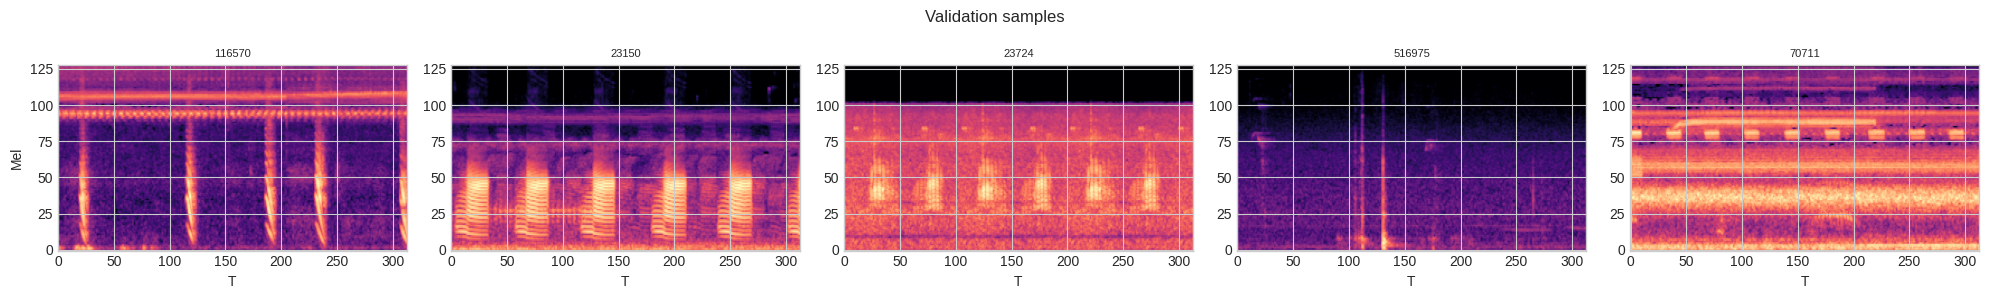

In [6]:
# Display 5 samples
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, ax in enumerate(axes):
    idx = i % len(ds_val)
    x, y = ds_val[idx]
    sp_idx = y.nonzero(as_tuple=True)[0]
    sp_names = [target_species[j] for j in sp_idx]
    ax.imshow(x.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(', '.join(sp_names), fontsize=8)
    ax.set_xlabel('T')
    if i == 0: ax.set_ylabel('Mel')
plt.suptitle('Validation samples')
plt.tight_layout()
plt.show()

## 4 — Augmentation side-by-side

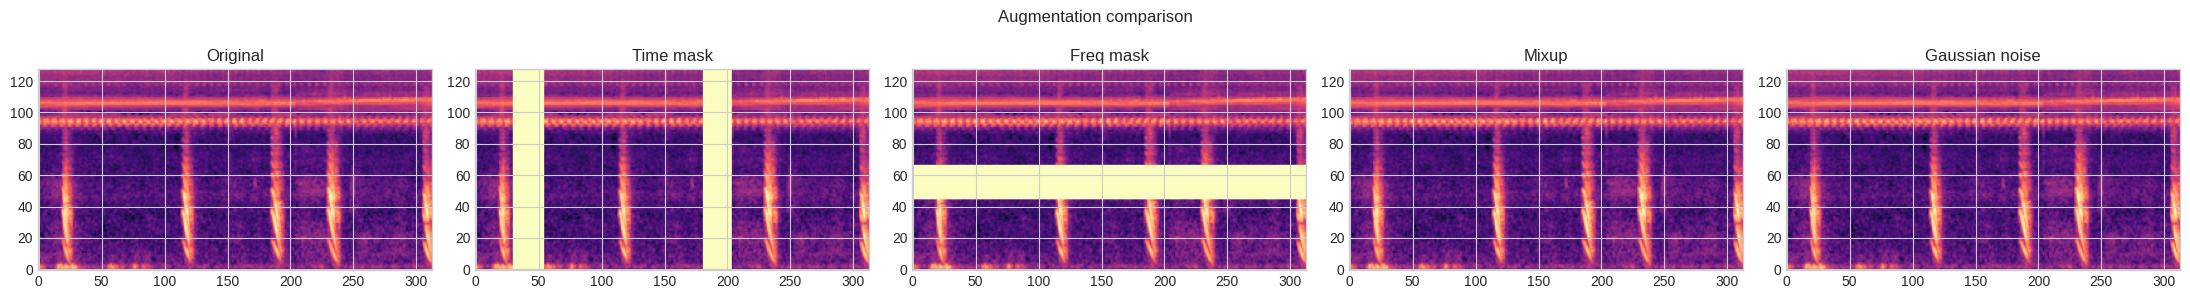

In [7]:
# Get a raw spectrogram crop
x_orig, y_orig = ds_val[0]
spec_np = x_orig.squeeze(0).numpy()

aug_time = spec_augment(spec_np.copy(), p=1.0, n_freq_masks=0)
aug_freq = spec_augment(spec_np.copy(), p=1.0, n_time_masks=0)
aug_noise = gaussian_noise(spec_np.copy(), p=1.0, std=0.03)

# Mixup with another sample
x2, y2 = ds_val[min(1, len(ds_val)-1)]
spec2 = x2.squeeze(0).numpy()
aug_mix, _ = mixup(spec_np.copy(), y_orig.numpy(), spec2.copy(), y2.numpy(), p=1.0)

titles = ['Original', 'Time mask', 'Freq mask', 'Mixup', 'Gaussian noise']
specs = [spec_np, aug_time, aug_freq, aug_mix, aug_noise]

fig, axes = plt.subplots(1, 5, figsize=(22, 3))
for ax, s, t in zip(axes, specs, titles):
    ax.imshow(s, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(t)
plt.suptitle('Augmentation comparison')
plt.tight_layout()
plt.show()

## 5 — Label vector spot-check

In [8]:
print('Label spot-check (5 samples):')
for i in range(min(5, len(ds_val))):
    row = ds_val.df.iloc[i]
    _, y = ds_val[i]
    active = [target_species[j] for j in y.nonzero(as_tuple=True)[0]]
    sec = ds_val.secondary_labels.get(row['filename'], [])
    print(f"  {row['filename'][:40]:40s}  primary={row['primary_label']:12s}  "
          f"secondary={sec}  label_active={active}")

Label spot-check (5 samples):
  116570/iNat1460166.ogg                    primary=116570        secondary=[]  label_active=['116570']
  23150/iNat1243039.ogg                     primary=23150         secondary=[]  label_active=['23150']
  23724/iNat249321.ogg                      primary=23724         secondary=[]  label_active=['23724']
  516975/iNat22239.ogg                      primary=516975        secondary=[]  label_active=['516975']
  70711/iNat1301472.ogg                     primary=70711         secondary=[]  label_active=['70711']


## 6 — Batch loading speed

In [9]:
# Time loading with the full augmentation pipeline
ds_bench = BirdCLEFDataset(
    folds_csv=sub_folds_path, fold=0, mode='train',
    spec_dir=SPEC_DIR, target_species=target_species,
    train_meta_csv=TRAIN_CSV, audio_dir=AUDIO_DIR,
)
loader = DataLoader(ds_bench, batch_size=32, shuffle=True, num_workers=0)

times = []
for batch_i, (xb, yb) in enumerate(loader):
    if batch_i == 0:
        t0 = time.time()
        continue
    if batch_i >= 5:
        break
    times.append(time.time() - t0)
    t0 = time.time()

if times:
    print(f'Batch shape: x={xb.shape}, y={yb.shape}')
    print(f'Avg batch load time: {np.mean(times)*1000:.0f} ms  '
          f'(min={np.min(times)*1000:.0f}, max={np.max(times)*1000:.0f})')
else:
    print('Not enough data for timing (need > 1 batch of 32).')
    # Fallback: time individual samples
    t0 = time.time()
    for i in range(min(32, len(ds_bench))):
        _ = ds_bench[i]
    elapsed = time.time() - t0
    print(f'32 individual samples in {elapsed*1000:.0f} ms ({elapsed/32*1000:.1f} ms/sample)')

Not enough data for timing (need > 1 batch of 32).
32 individual samples in 22 ms (0.7 ms/sample)


## Verdict

- [ ] Cached .npy files have expected shape and value range
- [ ] Dataset returns correct tensor shapes (1, 128, T)
- [ ] Augmentations visibly alter spectrograms as expected
- [ ] Label vectors match metadata
- [ ] Batch loading is fast (< 200 ms for batch of 32 from cache)